## Modelo clasificatorio de cancer de mama Naive Bayes

Fuente: Wolberg, W., Mangasarian, O., Street, N., & Street, W. (1993). Breast Cancer Wisconsin (Diagnostic) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DW2B.

Dataset:
https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

Es recomendado leer el dataset para comprender mejor el contexto de la información antes de trabajar en el código.

In [4]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
# Step 2: Load dataset into a pandas DataFrame
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
df['target_name'] = df['target'].map({0: 'malignant', 1: 'benign'})

df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0,malignant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0,malignant
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0,malignant
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0,malignant
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0,malignant


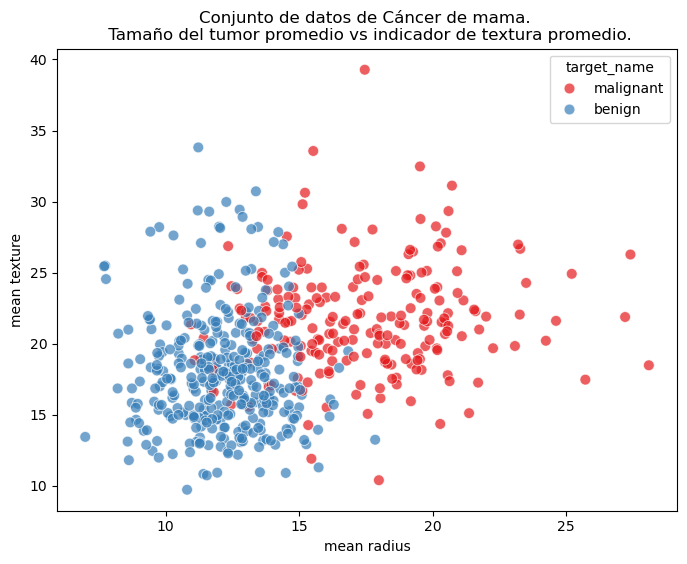

In [15]:
# Step 3: Scatter plot of two features (for visualization only)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="mean radius",
    y="mean texture",
    hue="target_name",
    palette="Set1",
    s=60,
    alpha=0.7
)
plt.title("Conjunto de datos de Cáncer de mama. \n Tamaño del tumor promedio vs indicador de textura promedio.")
plt.show()

In [7]:
# Step 4: Split into Train/Test sets
X = df.drop(columns=['target', 'target_name']) # all vars
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=7,
    stratify=y
)

# Step 5: Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[-0.82826747,  3.27644737, -0.88304887, ..., -1.31723502,
         0.01042728, -0.60720503],
       [ 0.13481314,  0.10048088,  0.15710237, ...,  0.67419493,
        -0.29990242,  0.47919446],
       [-0.03071634,  0.31085473, -0.04969849, ..., -0.71215395,
        -1.05401967,  0.02201462],
       ...,
       [-0.66574762, -0.26823888, -0.6982014 , ..., -0.66255715,
        -1.48976759, -0.81535195],
       [-0.33468866, -1.35856355, -0.3548505 , ...,  0.02864917,
        -0.84016553,  0.05440483],
       [-0.92156591, -1.57798574, -0.95549504, ..., -1.28700458,
        -1.22445982, -0.95978043]], shape=(398, 30))

In [8]:
# Step 6: Train Naive Bayes model
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

,priors,None
,var_smoothing,1e-09


In [34]:
# Clasificación
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Test y train split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=7)


# Construimos un modelo para el train
X_train = sm.add_constant(x_train)
#model = sm.Logit(y_train, X_train).fit(disp=False)

# Prediccion
X_test = sm.add_constant(x_test)
y_pred_prob = model.predict(X_test)

# Convierte la predicción en etiqueta
y_pred_class = (y_pred_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

In [35]:
# Show confusion matrix values
print("matriz de confusion\n",cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred_class, target_names=cancer.target_names))

matriz de confusion
 [[72  2]
 [ 7 33]]

Classification Report:
               precision    recall  f1-score   support

   malignant       0.91      0.97      0.94        74
      benign       0.94      0.82      0.88        40

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114



In [9]:
# Step 7: Predictions
y_pred = nb.predict(X_test_scaled)

# Step 8: Evaluation
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=cancer.target_names
))


Confusion Matrix:

[[ 59   5]
 [  6 101]]

Classification Report:

              precision    recall  f1-score   support

   malignant       0.91      0.92      0.91        64
      benign       0.95      0.94      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



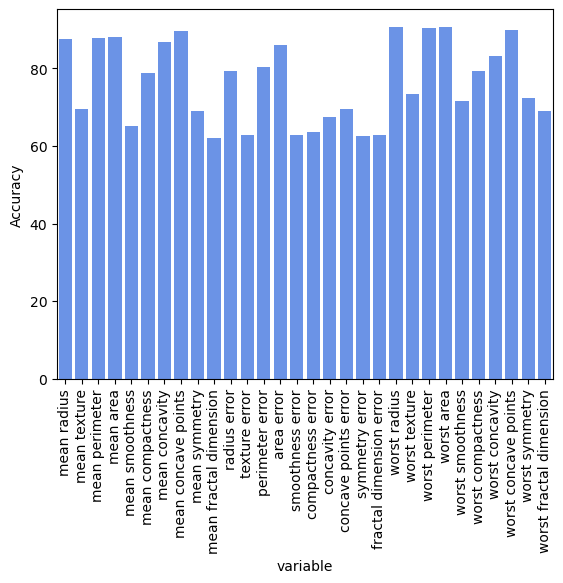

In [10]:
## Coefficient information criterion

results = []

for variable in X.columns:

    X_var = X_train[[variable]]

    nb = GaussianNB()
    nb.fit(X_var, y_train)

    # Predicting to get the accuracy

    y_pred = nb.predict(X_var)

    accuracy = np.mean(y_train == y_pred) * 100

    results.append({
        'variable': variable,
        'Accuracy': accuracy
        })


# Output table and figure
results_df = pd.DataFrame(results)

results_df = results_df#.sort_values('Accuracy', ascending = 0)

ax = sns.barplot(results_df, x = 'variable', y = 'Accuracy', orient = 'v')
ax.tick_params(axis='x', labelrotation=90)

In [11]:
variable = ['worst area',
            'worst radius',
            'worst perimeter']

X_var = X_train[variable]

nb = GaussianNB()
nb.fit(X_var, y_train)

# Step 7: Predictions
y_pred = nb.predict(X_var)


# Step 8: Evaluation
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_train, y_pred))


print("\nClassification Report:\n")
print(classification_report(
    y_train,
    y_pred,
    target_names=cancer.target_names
))


Confusion Matrix:

[[125  23]
 [  9 241]]

Classification Report:

              precision    recall  f1-score   support

   malignant       0.93      0.84      0.89       148
      benign       0.91      0.96      0.94       250

    accuracy                           0.92       398
   macro avg       0.92      0.90      0.91       398
weighted avg       0.92      0.92      0.92       398

